In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
import sys
sys.path.append('..')
from pipeline.defender import evaluate_model

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
clean_df = pd.read_csv('../data/featured_transactions_v1.csv')
clean_df['Timestamp'] = pd.to_datetime(clean_df['Timestamp'])
cutoff = clean_df['Timestamp'].quantile(0.8)
test = clean_df[clean_df['Timestamp'] > cutoff]


attacked_datasets = {
    'amount_scaling': pd.read_csv('../data/attacked_transactions_amount_scaling.csv'),
    'category_mimicry': pd.read_csv('../data/attacked_transactions_category_mimicry.csv'),
    'time_shift': pd.read_csv('../data/attacked_transactions_time_shift.csv'),
    'combined': pd.read_csv('../data/attacked_transactions_combined.csv')
}

model_names = ['lr_balanced', 'rf_balanced', 'xgb_balanced', 'lr_naive', 'rf_naive', 'xgb_naive']
models = {name: joblib.load(f'../results/models/{name}.pkl') for name in model_names}

print(f"Clean test data shape: {test.shape}")
print(f"Models loaded: {list(models.keys())}")

Clean test data shape: (41186, 11)
Models loaded: ['lr_balanced', 'rf_balanced', 'xgb_balanced', 'lr_naive', 'rf_naive', 'xgb_naive']


In [4]:
feature_cols = ['amount_zscore', 'transactions_last_1h', 'transactions_last_24h', 'time_since_last_txn', 'is_new_category', 'is_foreign']

scaler = joblib.load('../results/models/scaler.pkl')
X_clean = pd.DataFrame(scaler.transform(test[feature_cols]),columns=feature_cols)
y_clean = test['is_fraud']

results = []

for model_name, model in models.items():
    base = evaluate_model(model, X_clean, y_clean)

    for attacker_name, attacked_df in attacked_datasets.items():
        X_attacked = pd.DataFrame(scaler.transform(attacked_df[feature_cols]),columns=feature_cols)
        y_attacked = attacked_df['is_fraud']
        attacked = evaluate_model(model, X_attacked, y_attacked)

        results.append({
            'model': model_name,
            'attacker': attacker_name,
            'clean_recall': base['recall'],
            'attacked_recall': attacked['recall'],
            'recall_drop': base['recall'] - attacked['recall'],
            'clean_f1': base['f1_score'],
            'attacked_f1': attacked['f1_score']
        })

results_df = pd.DataFrame(results)

print(results_df)

           model          attacker  clean_recall  attacked_recall  \
0    lr_balanced    amount_scaling      0.582598         0.767970   
1    lr_balanced  category_mimicry      0.582598         0.552333   
2    lr_balanced        time_shift      0.582598         0.775536   
3    lr_balanced          combined      0.582598         0.476671   
4    rf_balanced    amount_scaling      0.760404         0.788146   
5    rf_balanced  category_mimicry      0.760404         0.640605   
6    rf_balanced        time_shift      0.760404         0.824716   
7    rf_balanced          combined      0.760404         0.540984   
8   xgb_balanced    amount_scaling      0.778058         0.794451   
9   xgb_balanced  category_mimicry      0.778058         0.678436   
10  xgb_balanced        time_shift      0.778058         0.857503   
11  xgb_balanced          combined      0.778058         0.542245   
12      lr_naive    amount_scaling      0.200504         0.286255   
13      lr_naive  category_mimicry

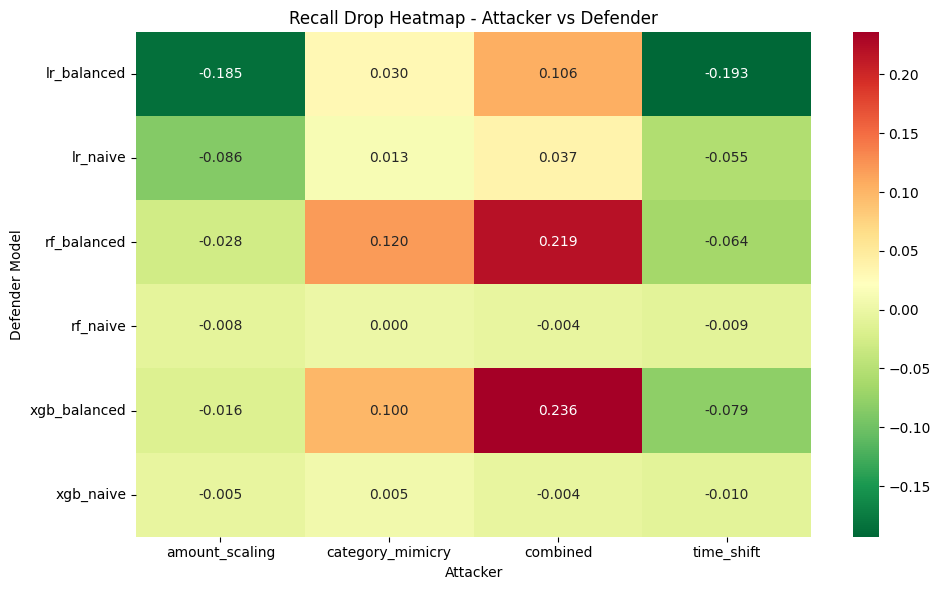

In [5]:
heatmap_data = results_df.pivot(index='model', columns='attacker', values='recall_drop')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r')
plt.title('Recall Drop Heatmap - Attacker vs Defender')
plt.ylabel('Defender Model')
plt.xlabel('Attacker')
plt.tight_layout()
plt.show()

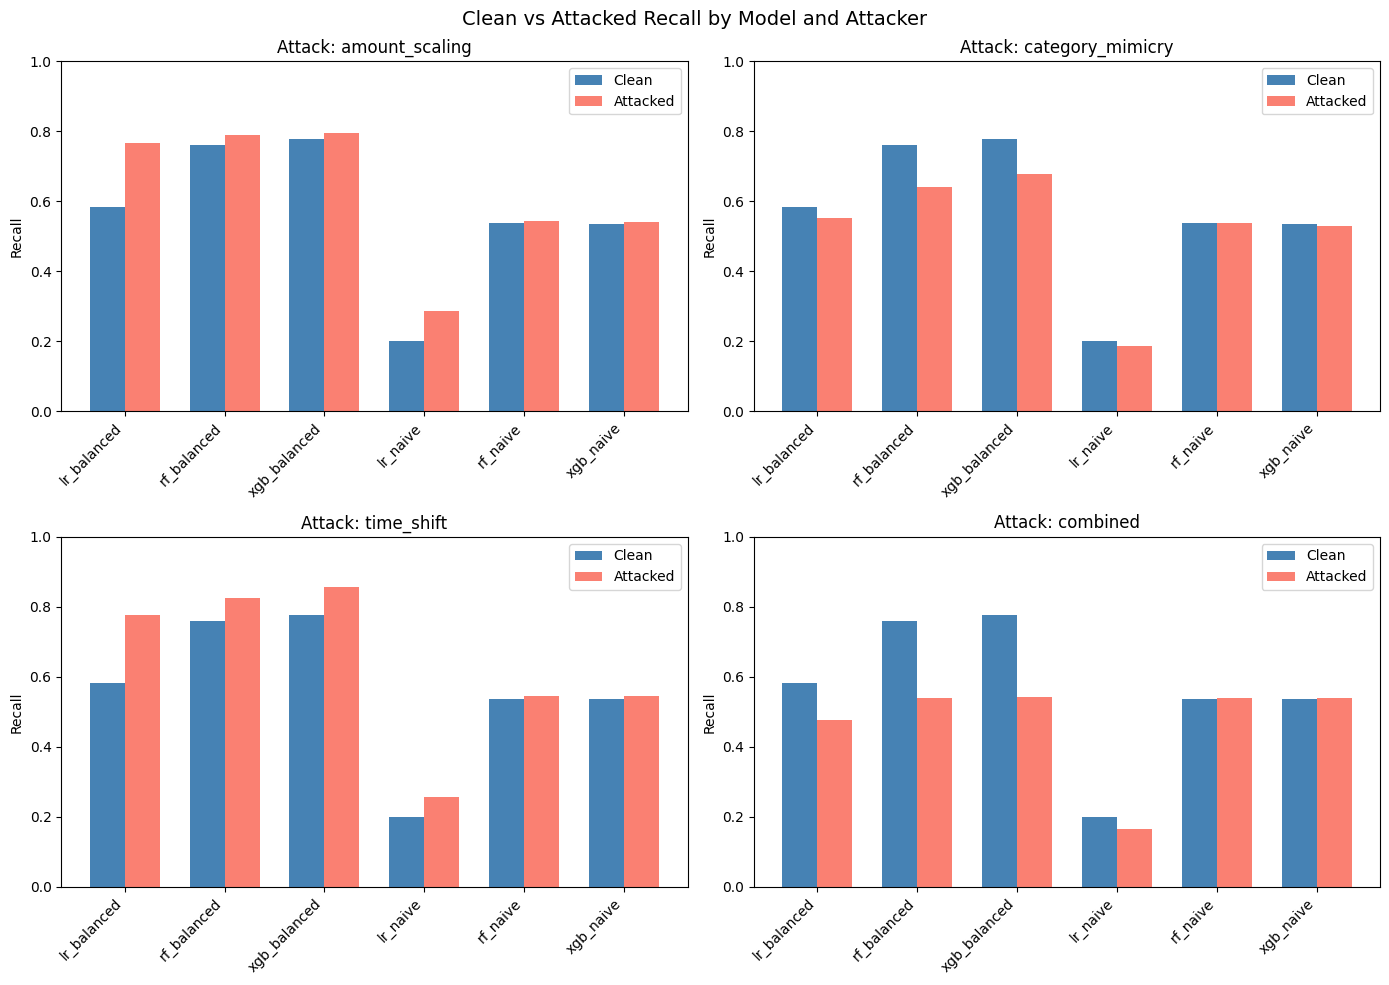

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

attackers = results_df['attacker'].unique()

for i, attacker in enumerate(attackers):
    ax = axes[i]
    attacker_data = results_df[results_df['attacker'] == attacker]
    
    x = np.arange(len(attacker_data))
    width = 0.35
    
    # plot clean recall bars
    ax.bar(x - width/2, attacker_data['clean_recall'], width, label='Clean', color='steelblue')
    
    # plot attacked recall bars — have a go at this line
    ax.bar(x + width/2, attacker_data['attacked_recall'], width, label='Attacked', color='salmon')
    
    ax.set_title(f'Attack: {attacker}')
    ax.set_xticks(x)
    ax.set_xticklabels(attacker_data['model'], rotation=45, ha='right')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Clean vs Attacked Recall by Model and Attacker', fontsize=14)
plt.tight_layout()
plt.show()

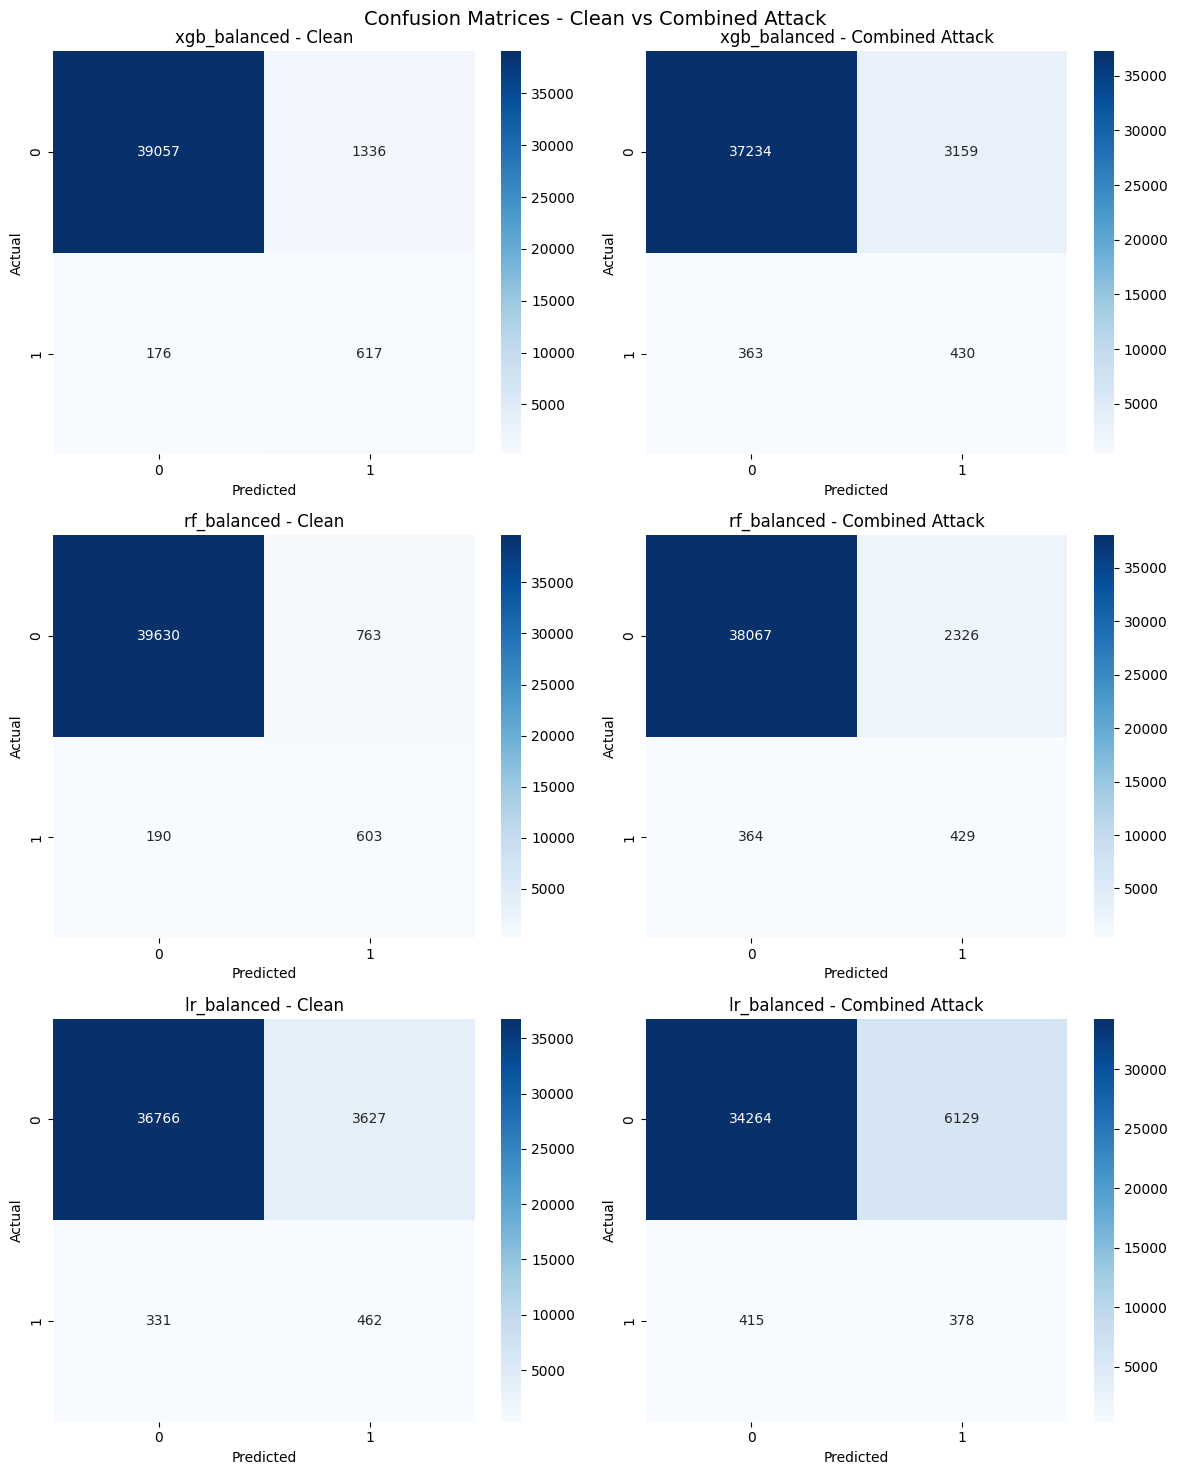

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

models_to_plot = ['xgb_balanced', 'rf_balanced', 'lr_balanced']

for i, model_name in enumerate(models_to_plot):
    model = models[model_name]
    
    # clean predictions
    y_pred_clean = model.predict(X_clean)
    
    # attacked predictions
    y_pred_attacked = model.predict(X_attacked_combined)
    
    # plot clean
    cm_clean = confusion_matrix(y_clean, y_pred_clean)
    sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', ax=axes[i][0])
    axes[i][0].set_title(f'{model_name} - Clean')
    axes[i][0].set_ylabel('Actual')
    axes[i][0].set_xlabel('Predicted')
    
    # plot attacked
    cm_attacked = confusion_matrix(y_attacked_combined, y_pred_attacked)
    sns.heatmap(cm_attacked, annot=True, fmt='d', cmap='Blues', ax=axes[i][1])
    axes[i][1].set_title(f'{model_name} - Combined Attack')
    axes[i][1].set_ylabel('Actual')
    axes[i][1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - Clean vs Combined Attack', fontsize=14)
plt.tight_layout()
plt.show()